## Did you like the movie? - Exploratory Data Analysis stage

### Import Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the dataset

In [20]:
movies = pd.read_csv('Team6_clean.csv',index_col='Title')
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, (500) Days of Summer to The Social Network
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             200 non-null    int64  
 1   Runtime          200 non-null    int64  
 2   Genre            200 non-null    object 
 3   Budget           199 non-null    float64
 4   Revenue          199 non-null    float64
 5   Personal         200 non-null    int64  
 6   IMDb             200 non-null    int64  
 7   Rotten_Tomatoes  200 non-null    int64  
 8   Metacritic       199 non-null    float64
 9   Filmaffinity     200 non-null    int64  
 10  P1               181 non-null    float64
 11  P2               174 non-null    float64
 12  P3               179 non-null    float64
 13  P4               181 non-null    float64
 14  P5               187 non-null    float64
 15  P6               188 non-null    float64
 16  P7               179 non-null    

In [21]:
movies.columns

Index(['Year', 'Runtime', 'Genre', 'Budget', 'Revenue', 'Personal', 'IMDb',
       'Rotten_Tomatoes', 'Metacritic', 'Filmaffinity', 'P1', 'P2', 'P3', 'P4',
       'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15',
       'P16', 'P17', 'P18', 'P19', 'P20'],
      dtype='object')

In [22]:
#movies.drop(columns=['Unnamed: 31'],inplace=True) # If this column does not exist in your dataframe comment out this line

### Exploring the dataset

Let's explore our dataset so we can have a glipse of the data.

In [23]:
movies.head()

,Year,Runtime,Genre,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,...,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20
Title,,,,,,,,,,,,,,,,,,,,,
(500) Days of Summer,2009,95,Romance,7.5,61.0,40,76,86,76.0,68,...,80.0,12.0,NaN,80.0,99.0,78.0,80.0,99.0,76.0,56.0
10 Things I Hate About You,1999,97,Romance,13.0,54.0,60,74,71,70.0,59,...,80.0,78.0,43.0,88.0,61.0,89.0,22.0,86.0,58.0,93.0
28 days later,2002,113,Horror,8.0,85.7,85,75,87,73.0,67,...,NaN,43.0,90.0,17.0,100.0,78.0,0.0,78.0,81.0,92.0
A Star is Born,2018,135,Romance,36.0,436.2,70,76,90,88.0,68,...,76.0,83.0,11.0,77.0,99.0,90.0,77.0,73.0,83.0,94.0
Adaptation (Ladron de Orquideas),2002,114,Comedy,19.0,32.8,95,77,91,83.0,74,...,37.0,78.0,25.0,11.0,85.0,72.0,61.0,91.0,80.0,86.0


In [24]:
movies.tail()

,Year,Runtime,Genre,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,...,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20
Title,,,,,,,,,,,,,,,,,,,,,
Schindler?s List,1993,195,Historical,22.0,322.0,98,89,98,93.0,99,...,79.0,79.0,84.0,77.0,93.0,85.0,66.0,86.0,84.0,92.0
Sicario,2015,122,Crime,30.0,85.0,90,76,93,84.0,91,...,98.0,13.0,94.0,98.0,37.0,48.0,84.0,90.0,NaN,90.0
Slumdog Millionaire,2008,120,Drama,15.0,378.0,87,80,91,86.0,88,...,27.0,99.0,NaN,NaN,54.0,82.0,30.0,NaN,86.0,77.0
The Silence of the Lambs,1991,118,Horror,19.0,273.0,96,86,96,85.0,97,...,90.0,20.0,59.0,85.0,71.0,90.0,46.0,88.0,78.0,0.0
The Social Network,2010,120,Drama,40.0,225.0,92,77,96,95.0,93,...,97.0,84.0,84.0,22.0,100.0,80.0,84.0,90.0,76.0,NaN


In [25]:
movies.shape

(200, 30)

In [26]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, (500) Days of Summer to The Social Network
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             200 non-null    int64  
 1   Runtime          200 non-null    int64  
 2   Genre            200 non-null    object 
 3   Budget           199 non-null    float64
 4   Revenue          199 non-null    float64
 5   Personal         200 non-null    int64  
 6   IMDb             200 non-null    int64  
 7   Rotten_Tomatoes  200 non-null    int64  
 8   Metacritic       199 non-null    float64
 9   Filmaffinity     200 non-null    int64  
 10  P1               181 non-null    float64
 11  P2               174 non-null    float64
 12  P3               179 non-null    float64
 13  P4               181 non-null    float64
 14  P5               187 non-null    float64
 15  P6               188 non-null    float64
 16  P7               179 non-null    

In [27]:
movies.iloc[:,:10].describe()

,Year,Runtime,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity
count,200.000000,200.000000,199.000000,199.000000,200.000000,200.000000,200.000000,199.000000,200.000000
mean,2006.350000,126.535000,73.566834,414.496985,79.840000,78.655000,86.545000,77.145729,77.025000
std,14.922497,23.655585,86.764121,515.116529,16.956474,6.153479,11.492535,12.192226,11.374589
min,1922.000000,81.000000,1.000000,4.100000,15.000000,52.000000,32.000000,33.000000,43.000000
25%,1999.000000,109.000000,14.000000,80.000000,73.000000,75.000000,81.750000,69.000000,69.000000
50%,2010.000000,122.500000,40.000000,235.000000,85.000000,79.000000,90.000000,78.000000,77.000000
75%,2017.000000,139.250000,109.000000,539.650000,91.000000,83.000000,94.000000,86.500000,86.000000
max,2025.000000,195.000000,460.000000,2920.000000,100.000000,94.000000,100.000000,100.000000,99.000000


Modify the following line so it includes only the surveyed data.

In [28]:
movies.iloc[:,10:].describe()

,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20
count,181.000000,174.000000,179.000000,181.000000,187.000000,188.000000,179.000000,176.000000,176.000000,181.000000,186.000000,184.000000,174.000000,181.000000,177.000000,180.000000,185.000000,179.000000,179.000000,186.000000
mean,72.016575,71.183908,71.351955,72.143646,70.101604,69.670213,73.195531,71.585227,69.585227,68.955801,72.048387,70.538043,66.264368,70.055249,73.604520,72.538889,68.740541,71.888268,72.709497,71.413978
std,24.244008,25.528644,25.345348,23.423903,25.193132,25.200114,23.559410,26.450679,24.794322,27.457608,25.179632,25.370450,29.432380,27.327179,22.381039,26.024776,26.512256,26.510096,24.709423,24.955650
min,0.000000,0.000000,0.000000,11.000000,12.000000,12.000000,13.000000,11.000000,12.000000,0.000000,11.000000,0.000000,11.000000,11.000000,12.000000,12.000000,0.000000,0.000000,11.000000,0.000000
25%,55.000000,54.250000,60.000000,56.000000,52.500000,52.000000,59.500000,58.750000,50.500000,47.000000,58.250000,54.750000,40.000000,52.000000,60.000000,58.500000,53.000000,56.500000,59.500000,57.000000
50%,80.000000,81.000000,80.000000,80.000000,80.000000,79.000000,80.000000,81.000000,79.500000,81.000000,80.000000,80.000000,79.000000,80.000000,81.000000,82.500000,79.000000,80.000000,81.000000,80.000000
75%,91.000000,89.750000,91.000000,90.000000,90.000000,90.000000,93.000000,92.000000,89.000000,90.000000,92.000000,89.000000,92.000000,91.000000,90.000000,91.000000,89.000000,91.500000,91.000000,89.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


### Missing data

We can check for missing data by calling `pd.isnull().sum()`. The table displays the number of records with missing data for each variable.

In [29]:
movies.isnull().sum()

Year                0
Runtime             0
Genre               0
Budget              1
Revenue             1
Personal            0
IMDb                0
Rotten_Tomatoes     0
Metacritic          1
Filmaffinity        0
P1                 19
P2                 26
P3                 21
P4                 19
P5                 13
P6                 12
P7                 21
P8                 24
P9                 24
P10                19
P11                14
P12                16
P13                26
P14                19
P15                23
P16                20
P17                15
P18                21
P19                21
P20                14
dtype: int64

#### Fan ratings and team member ratings

We will create a new column, `Fans`, with the average of fan ratings columns. If your dataset includes columns with each member ratings, use the following procedure for creating a `Personal` column aggregating all team members' ratings.

In [30]:
movies.iloc[:,10:]

,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20
Title,,,,,,,,,,,,,,,,,,,,
(500) Days of Summer,83.0,79.0,100.0,77.0,NaN,81.0,95.0,94.0,46.0,90.0,80.0,12.0,NaN,80.0,99.0,78.0,80.0,99.0,76.0,56.0
10 Things I Hate About You,20.0,73.0,76.0,38.0,96.0,92.0,90.0,67.0,88.0,95.0,80.0,78.0,43.0,88.0,61.0,89.0,22.0,86.0,58.0,93.0
28 days later,81.0,NaN,80.0,99.0,64.0,20.0,NaN,45.0,51.0,67.0,NaN,43.0,90.0,17.0,100.0,78.0,0.0,78.0,81.0,92.0
A Star is Born,93.0,83.0,84.0,86.0,94.0,18.0,41.0,86.0,90.0,44.0,76.0,83.0,11.0,77.0,99.0,90.0,77.0,73.0,83.0,94.0
Adaptation (Ladron de Orquideas),24.0,19.0,71.0,25.0,80.0,20.0,89.0,NaN,78.0,87.0,37.0,78.0,25.0,11.0,85.0,72.0,61.0,91.0,80.0,86.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Schindler?s List,16.0,25.0,76.0,76.0,94.0,NaN,100.0,18.0,NaN,76.0,79.0,79.0,84.0,77.0,93.0,85.0,66.0,86.0,84.0,92.0
Sicario,85.0,NaN,77.0,15.0,77.0,60.0,98.0,32.0,28.0,80.0,98.0,13.0,94.0,98.0,37.0,48.0,84.0,90.0,NaN,90.0
Slumdog Millionaire,NaN,61.0,15.0,95.0,49.0,79.0,77.0,NaN,72.0,13.0,27.0,99.0,NaN,NaN,54.0,82.0,30.0,NaN,86.0,77.0


In Python we can aggregate columns using the mean via `pd.iloc[row_range,column_range].mean(axis=1)`.

In [31]:
movies.iloc[:,10:].mean(axis=1)

Title
(500) Days of Summer                78.055556
10 Things I Hate About You          71.650000
28 days later                       63.882353
A Star is Born                      74.100000
Adaptation (Ladron de Orquideas)    58.894737
                                      ...    
Schindler?s List                    72.555556
Sicario                             66.888889
Slumdog Millionaire                 61.066667
The Silence of the Lambs            66.350000
The Social Network                  73.500000
Length: 200, dtype: float64

Now we create a column, `Fans`, with the above data.

In [32]:
movies['Fans']=movies.iloc[:,10:].mean(axis=1)
movies.head()

,Year,Runtime,Genre,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,...,P12,P13,P14,P15,P16,P17,P18,P19,P20,Fans
Title,,,,,,,,,,,,,,,,,,,,,
(500) Days of Summer,2009,95,Romance,7.5,61.0,40,76,86,76.0,68,...,12.0,NaN,80.0,99.0,78.0,80.0,99.0,76.0,56.0,78.055556
10 Things I Hate About You,1999,97,Romance,13.0,54.0,60,74,71,70.0,59,...,78.0,43.0,88.0,61.0,89.0,22.0,86.0,58.0,93.0,71.650000
28 days later,2002,113,Horror,8.0,85.7,85,75,87,73.0,67,...,43.0,90.0,17.0,100.0,78.0,0.0,78.0,81.0,92.0,63.882353
A Star is Born,2018,135,Romance,36.0,436.2,70,76,90,88.0,68,...,83.0,11.0,77.0,99.0,90.0,77.0,73.0,83.0,94.0,74.100000
Adaptation (Ladron de Orquideas),2002,114,Comedy,19.0,32.8,95,77,91,83.0,74,...,78.0,25.0,11.0,85.0,72.0,61.0,91.0,80.0,86.0,58.894737


Now that we aggregated the surveyed data, we can drop columns `P1` through `P20`. First, we create a list of the columns to be dropped to make sure we won't drop a needed column.

In [33]:
dropped_columns=movies.iloc[:,10:30].columns
dropped_columns

Index(['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11',
       'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P20'],
      dtype='object')

Next, we actually drop such columns and verify that it worked.

In [34]:
movies.drop(columns=dropped_columns,inplace=True)
movies.head()

,Year,Runtime,Genre,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
Title,,,,,,,,,,,
(500) Days of Summer,2009,95,Romance,7.5,61.0,40,76,86,76.0,68,78.055556
10 Things I Hate About You,1999,97,Romance,13.0,54.0,60,74,71,70.0,59,71.650000
28 days later,2002,113,Horror,8.0,85.7,85,75,87,73.0,67,63.882353
A Star is Born,2018,135,Romance,36.0,436.2,70,76,90,88.0,68,74.100000
Adaptation (Ladron de Orquideas),2002,114,Comedy,19.0,32.8,95,77,91,83.0,74,58.894737


In [35]:
movies.describe()

,Year,Runtime,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
count,200.000000,200.000000,199.000000,199.000000,200.000000,200.000000,200.000000,199.000000,200.000000,200.000000
mean,2006.350000,126.535000,73.566834,414.496985,79.840000,78.655000,86.545000,77.145729,77.025000,70.948057
std,14.922497,23.655585,86.764121,515.116529,16.956474,6.153479,11.492535,12.192226,11.374589,6.017400
min,1922.000000,81.000000,1.000000,4.100000,15.000000,52.000000,32.000000,33.000000,43.000000,55.562500
25%,1999.000000,109.000000,14.000000,80.000000,73.000000,75.000000,81.750000,69.000000,69.000000,66.396324
50%,2010.000000,122.500000,40.000000,235.000000,85.000000,79.000000,90.000000,78.000000,77.000000,71.575000
75%,2017.000000,139.250000,109.000000,539.650000,91.000000,83.000000,94.000000,86.500000,86.000000,75.108359
max,2025.000000,195.000000,460.000000,2920.000000,100.000000,94.000000,100.000000,100.000000,99.000000,85.066667


#### Dropping records with null values

There are several methods to deal with missing data.

In [36]:
movies.isnull().sum()

Year               0
Runtime            0
Genre              0
Budget             1
Revenue            1
Personal           0
IMDb               0
Rotten_Tomatoes    0
Metacritic         1
Filmaffinity       0
Fans               0
dtype: int64

For `Filmaffinity`, we impute null values with the column mean value.

In [37]:
i_mean = movies['IMDb'].mean()
i_mean
r_mean = movies['Revenue'].mean()
r_mean
b_mean = movies['Budget'].mean()
b_mean

np.float64(73.56683417085428)

In [38]:
#movies['Filmaffinity'].fillna(fa_mean,inplace=True)
movies.fillna({'IMDb':i_mean},inplace=True)
movies.fillna({'Revenue':r_mean},inplace=True)
movies.fillna({'Budget':b_mean},inplace=True)
movies.isnull().sum()

Year               0
Runtime            0
Genre              0
Budget             0
Revenue            0
Personal           0
IMDb               0
Rotten_Tomatoes    0
Metacritic         1
Filmaffinity       0
Fans               0
dtype: int64

Now, we drop the records with null values.

In [39]:
movies.dropna(inplace=True)

In [40]:
movies.shape

(199, 11)

In [41]:
movies.isnull().sum()

Year               0
Runtime            0
Genre              0
Budget             0
Revenue            0
Personal           0
IMDb               0
Rotten_Tomatoes    0
Metacritic         0
Filmaffinity       0
Fans               0
dtype: int64

### Checking for duplicates

In order to check for duplicate entries, we will first capitalize index values.

In [42]:
movies.index=movies.index.str.title()

In [43]:
movies.head()

,Year,Runtime,Genre,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
Title,,,,,,,,,,,
(500) Days Of Summer,2009,95,Romance,7.5,61.0,40,76,86,76.0,68,78.055556
10 Things I Hate About You,1999,97,Romance,13.0,54.0,60,74,71,70.0,59,71.650000
28 Days Later,2002,113,Horror,8.0,85.7,85,75,87,73.0,67,63.882353
A Star Is Born,2018,135,Romance,36.0,436.2,70,76,90,88.0,68,74.100000
Adaptation (Ladron De Orquideas),2002,114,Comedy,19.0,32.8,95,77,91,83.0,74,58.894737


Now we check for duplicate entries.

In [44]:
duplicate_titles=movies[movies.index.duplicated()].index
movies.loc[duplicate_titles]

,Year,Runtime,Genre,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
Title,,,,,,,,,,,


And remove the duplicates, leaving the first record

In [45]:
movies = movies[~movies.index.duplicated(keep='first')]
movies.loc[duplicate_titles]

,Year,Runtime,Genre,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
Title,,,,,,,,,,,


In [46]:
movies.shape

(199, 11)

### Descriptive Statistics - Numeric data

Now that we have a cleaner version of our dataset, let's perform a descriptive statistics analysis of the data. In the process we will create graphs using **Seaborn**. Feel free to customize the plots to your liking.

#### Summary

In [47]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199 entries, (500) Days Of Summer to The Social Network
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             199 non-null    int64  
 1   Runtime          199 non-null    int64  
 2   Genre            199 non-null    object 
 3   Budget           199 non-null    float64
 4   Revenue          199 non-null    float64
 5   Personal         199 non-null    int64  
 6   IMDb             199 non-null    int64  
 7   Rotten_Tomatoes  199 non-null    int64  
 8   Metacritic       199 non-null    float64
 9   Filmaffinity     199 non-null    int64  
 10  Fans             199 non-null    float64
dtypes: float64(4), int64(6), object(1)
memory usage: 26.8+ KB


We observe that after removing duplictes and null values, we are left with 331 records with 11 attributes.

In [48]:
movies.describe()

,Year,Runtime,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
count,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000
mean,2006.407035,126.678392,73.923451,416.503000,79.834171,78.643216,86.477387,77.145729,77.020101,70.935513
std,14.938262,23.627947,86.616679,514.330783,16.999039,6.166736,11.481572,12.192226,11.403065,6.029953
min,1922.000000,81.000000,1.000000,4.100000,15.000000,52.000000,32.000000,33.000000,43.000000,55.562500
25%,1999.000000,109.500000,14.500000,81.500000,73.000000,75.000000,81.500000,69.000000,69.000000,66.380882
50%,2010.000000,123.000000,40.000000,244.000000,85.000000,79.000000,90.000000,78.000000,77.000000,71.500000
75%,2017.000000,139.500000,109.000000,539.650000,91.000000,83.000000,94.000000,86.500000,86.000000,75.111455
max,2025.000000,195.000000,460.000000,2920.000000,100.000000,94.000000,100.000000,100.000000,99.000000,85.066667


In [49]:
movies[movies['Filmaffinity']==movies['Filmaffinity'].max()]

,Year,Runtime,Genre,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
Title,,,,,,,,,,,
Schindler?S List,1993,195,Historical,22.0,322.0,98,89,98,93.0,99,72.555556


In [50]:
movies[movies['Metacritic']==movies['Metacritic'].min()]

,Year,Runtime,Genre,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
Title,,,,,,,,,,,
Five Nights At Freddy,2023,110,Horror,20.0,295.5,32,54,32,33.0,43,65.578947


We will cast `Year` as a string to make it a categorical variable

In [51]:
movies['Year']=movies['Year'].astype(int).astype(str)

Now, we display a statistical description of all numeric values, followed by a description of the categorical variables.

In [52]:
movies.describe()

,Runtime,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
count,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000
mean,126.678392,73.923451,416.503000,79.834171,78.643216,86.477387,77.145729,77.020101,70.935513
std,23.627947,86.616679,514.330783,16.999039,6.166736,11.481572,12.192226,11.403065,6.029953
min,81.000000,1.000000,4.100000,15.000000,52.000000,32.000000,33.000000,43.000000,55.562500
25%,109.500000,14.500000,81.500000,73.000000,75.000000,81.500000,69.000000,69.000000,66.380882
50%,123.000000,40.000000,244.000000,85.000000,79.000000,90.000000,78.000000,77.000000,71.500000
75%,139.500000,109.000000,539.650000,91.000000,83.000000,94.000000,86.500000,86.000000,75.111455
max,195.000000,460.000000,2920.000000,100.000000,94.000000,100.000000,100.000000,99.000000,85.066667


In [53]:
movies.describe(include=[object])

,Year,Genre
count,199,199
unique,53,20
top,2014,Action
freq,13,32


#### Detecting outliers

In order to detect outliers, we create boxplots for all numerical variables.

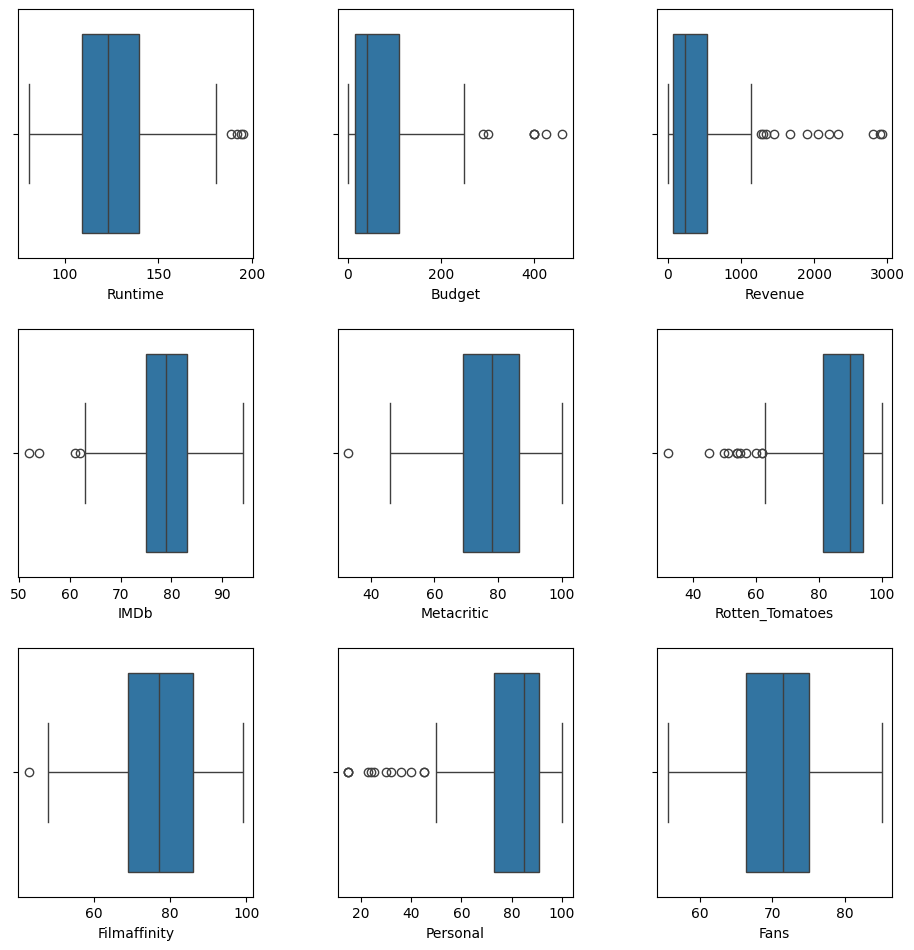

In [54]:
fig, axes = plt.subplots(3, 3,figsize=(10,10))
fig.tight_layout(pad=3)
sns.boxplot(x=movies['Runtime'], ax=axes[0,0]);
sns.boxplot(x=movies['Budget'], ax=axes[0,1]);
sns.boxplot(x=movies['Revenue'], ax=axes[0,2]);
sns.boxplot(x=movies['IMDb'], ax=axes[1,0]);
sns.boxplot(x=movies['Metacritic'], ax=axes[1,1]);
sns.boxplot(x=movies['Rotten_Tomatoes'], ax=axes[1,2]);
sns.boxplot(x=movies['Filmaffinity'], ax=axes[2,0]);
sns.boxplot(x=movies['Personal'], ax=axes[2,1]);
sns.boxplot(x=movies['Fans'], ax=axes[2,2]);

Our approach for removing outliers will be naive: We calculate the interquartile range, `IQR`, for all numerical variables, and remove all records more than `1.5*IQR` units from the nearest quartile. This reduces the interquartile range and will possible "create" more outliers, but they will be within the endpoints of the whiskers of the previous plots.

In [55]:
movies_numeric = movies.select_dtypes(include='number')

In [56]:
Q1 = movies_numeric.quantile(0.25)
Q3 = movies_numeric.quantile(0.75)
IQR = Q3 - Q1
IQR

Runtime             30.000000
Budget              94.500000
Revenue            458.150000
Personal            18.000000
IMDb                 8.000000
Rotten_Tomatoes     12.500000
Metacritic          17.500000
Filmaffinity        17.000000
Fans                 8.730573
dtype: float64

In [57]:
movies_outliers=movies[((movies_numeric < (Q1 - 1.5 * IQR)) |(movies_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]
movies_outliers

,Year,Runtime,Genre,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
Title,,,,,,,,,,,
(500) Days Of Summer,2009,95,Romance,7.5,61.0,40,76,86,76.0,68,78.055556
Avatar,2009,162,SciFi,237.0,2920.0,71,79,81,83.0,72,66.333333
Avatar: The Way Of Water,2022,192,SciFi,460.0,2320.0,69,75,76,67.0,65,72.500000
Avengers: Endgame,2019,181,Action,400.0,2800.0,15,84,94,78.0,73,72.562500
Avengers: Infinity War,2018,149,Action,400.0,2052.0,25,84,85,68.0,75,74.894737
Barbie,2023,114,Comedy,145.0,1447.0,15,68,88,80.0,58,64.375000
Black Panther,2018,135,Action,200.0,1348.3,75,73,96,88.0,63,72.235294
Black Swan,2010,108,Thriller,13.0,329.0,45,80,85,79.0,76,75.333333
Challengers,2024,131,Drama,96.0,55.0,80,64,62,80.0,64,69.222222


In [58]:
movies.drop(movies_outliers.index,inplace=True)
movies.shape

(161, 11)

We are left with 460 records, still enough for linear regression. Let's view the new boxplots.

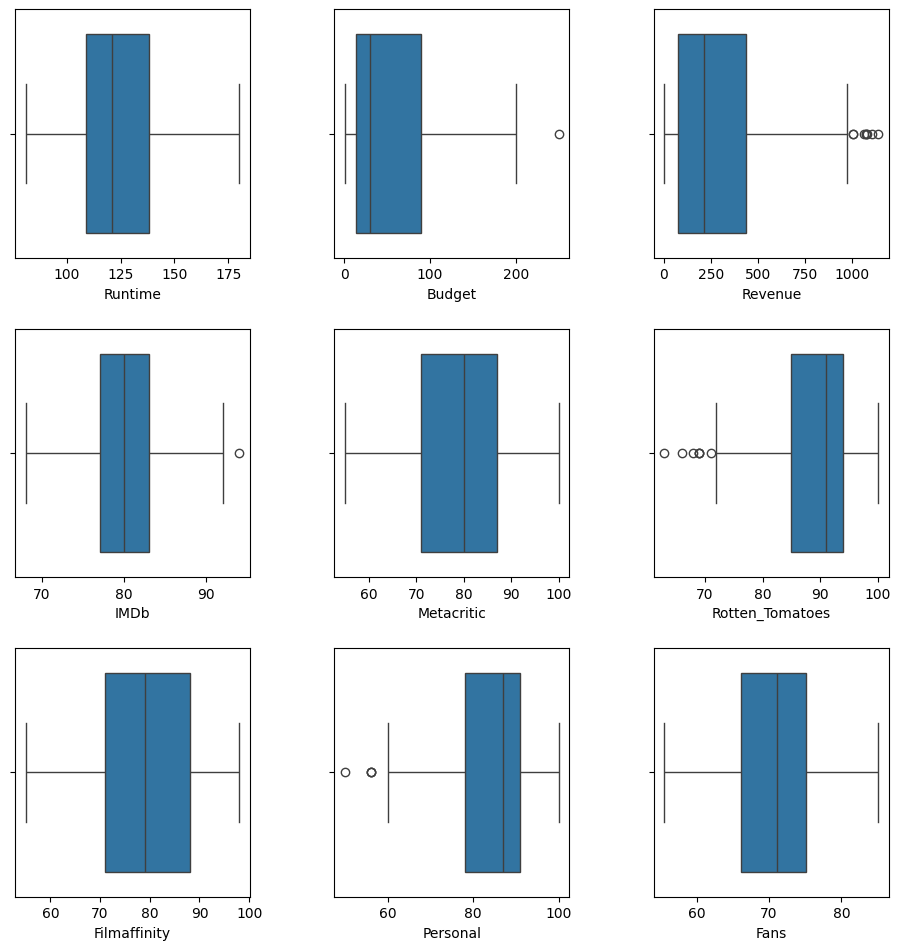

In [59]:
fig, axes = plt.subplots(3, 3,figsize=(10,10))
fig.tight_layout(pad=3)
sns.boxplot(x=movies['Runtime'], ax=axes[0,0]);
sns.boxplot(x=movies['Budget'], ax=axes[0,1]);
sns.boxplot(x=movies['Revenue'], ax=axes[0,2]);
sns.boxplot(x=movies['IMDb'], ax=axes[1,0]);
sns.boxplot(x=movies['Metacritic'], ax=axes[1,1]);
sns.boxplot(x=movies['Rotten_Tomatoes'], ax=axes[1,2]);
sns.boxplot(x=movies['Filmaffinity'], ax=axes[2,0]);
sns.boxplot(x=movies['Personal'], ax=axes[2,1]);
sns.boxplot(x=movies['Fans'], ax=axes[2,2]);

#### Saving clean DataFrame to `csv`file

Let's save the processed dataframe to a file

In [60]:
#movies.to_csv('Team6_final_2.csv')

#### Histograms and distributions

Let's explore the shape of the distributions of numeric variables via histograms.

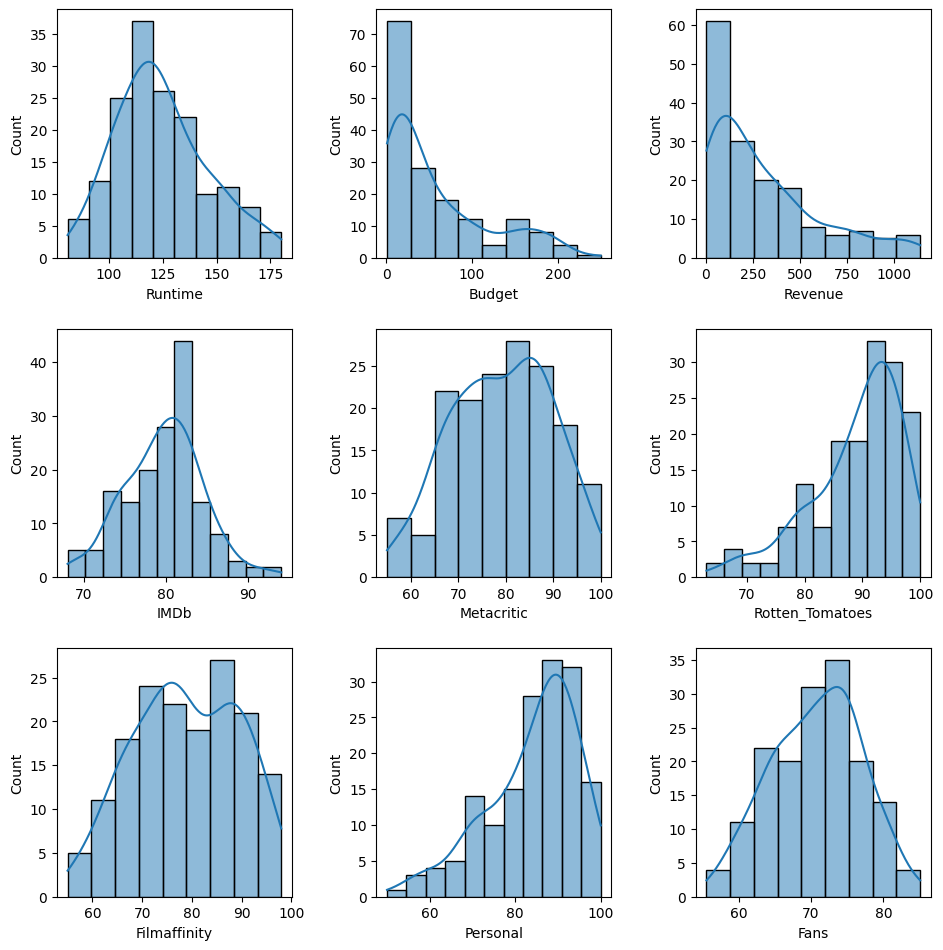

In [61]:
fig, axes = plt.subplots(3, 3,figsize=(10,10))
fig.tight_layout(pad=3)
sns.histplot(x=movies['Runtime'], kde=True, ax=axes[0,0]);
sns.histplot(x=movies['Budget'], kde=True, ax=axes[0,1]);
sns.histplot(x=movies['Revenue'], kde=True, ax=axes[0,2]);
sns.histplot(x=movies['IMDb'], kde=True, ax=axes[1,0]);
sns.histplot(x=movies['Metacritic'], kde=True, ax=axes[1,1]);
sns.histplot(x=movies['Rotten_Tomatoes'], kde=True, ax=axes[1,2]);
sns.histplot(x=movies['Filmaffinity'], kde=True, ax=axes[2,0]);
sns.histplot(x=movies['Personal'], kde=True, ax=axes[2,1]);
sns.histplot(x=movies['Fans'], kde=True, ax=axes[2,2]);

#### Distribution by `Year` and `Genre`

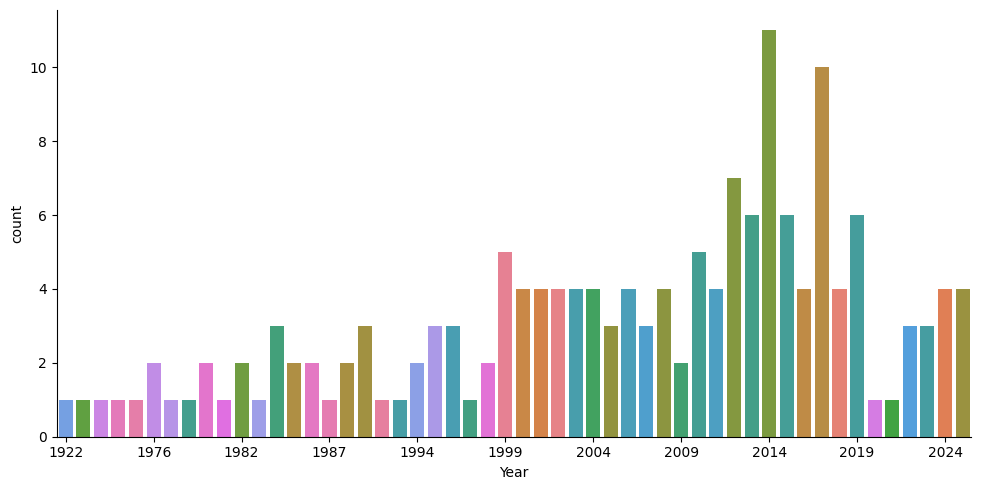

In [62]:
by_year = sns.catplot(x="Year", data=movies, aspect=2, kind="count", order=movies.Year.sort_values(), hue='Year')
by_year.set_xticklabels(step=5);

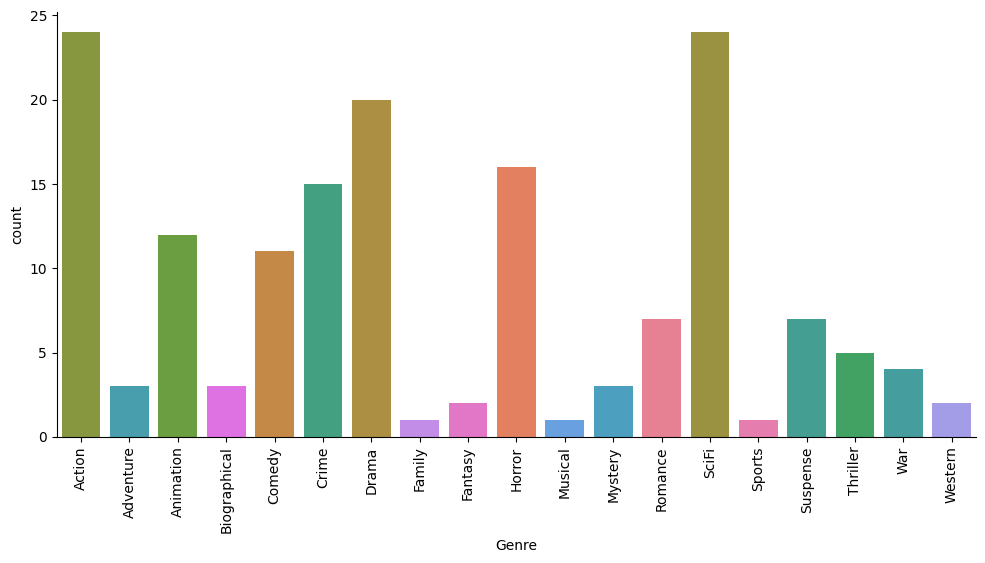

In [63]:
by_genre = sns.catplot(x="Genre", data=movies, aspect=2, kind="count", hue='Genre', order=movies.Genre.sort_values())
by_genre.set_xticklabels(rotation='vertical');

We see that the most popular movie genres are Action, Comedy, and Drama.

#### Correlations

Now we create some plots that display the correlation between variables. We leave the interpretation of these graphs to the student.

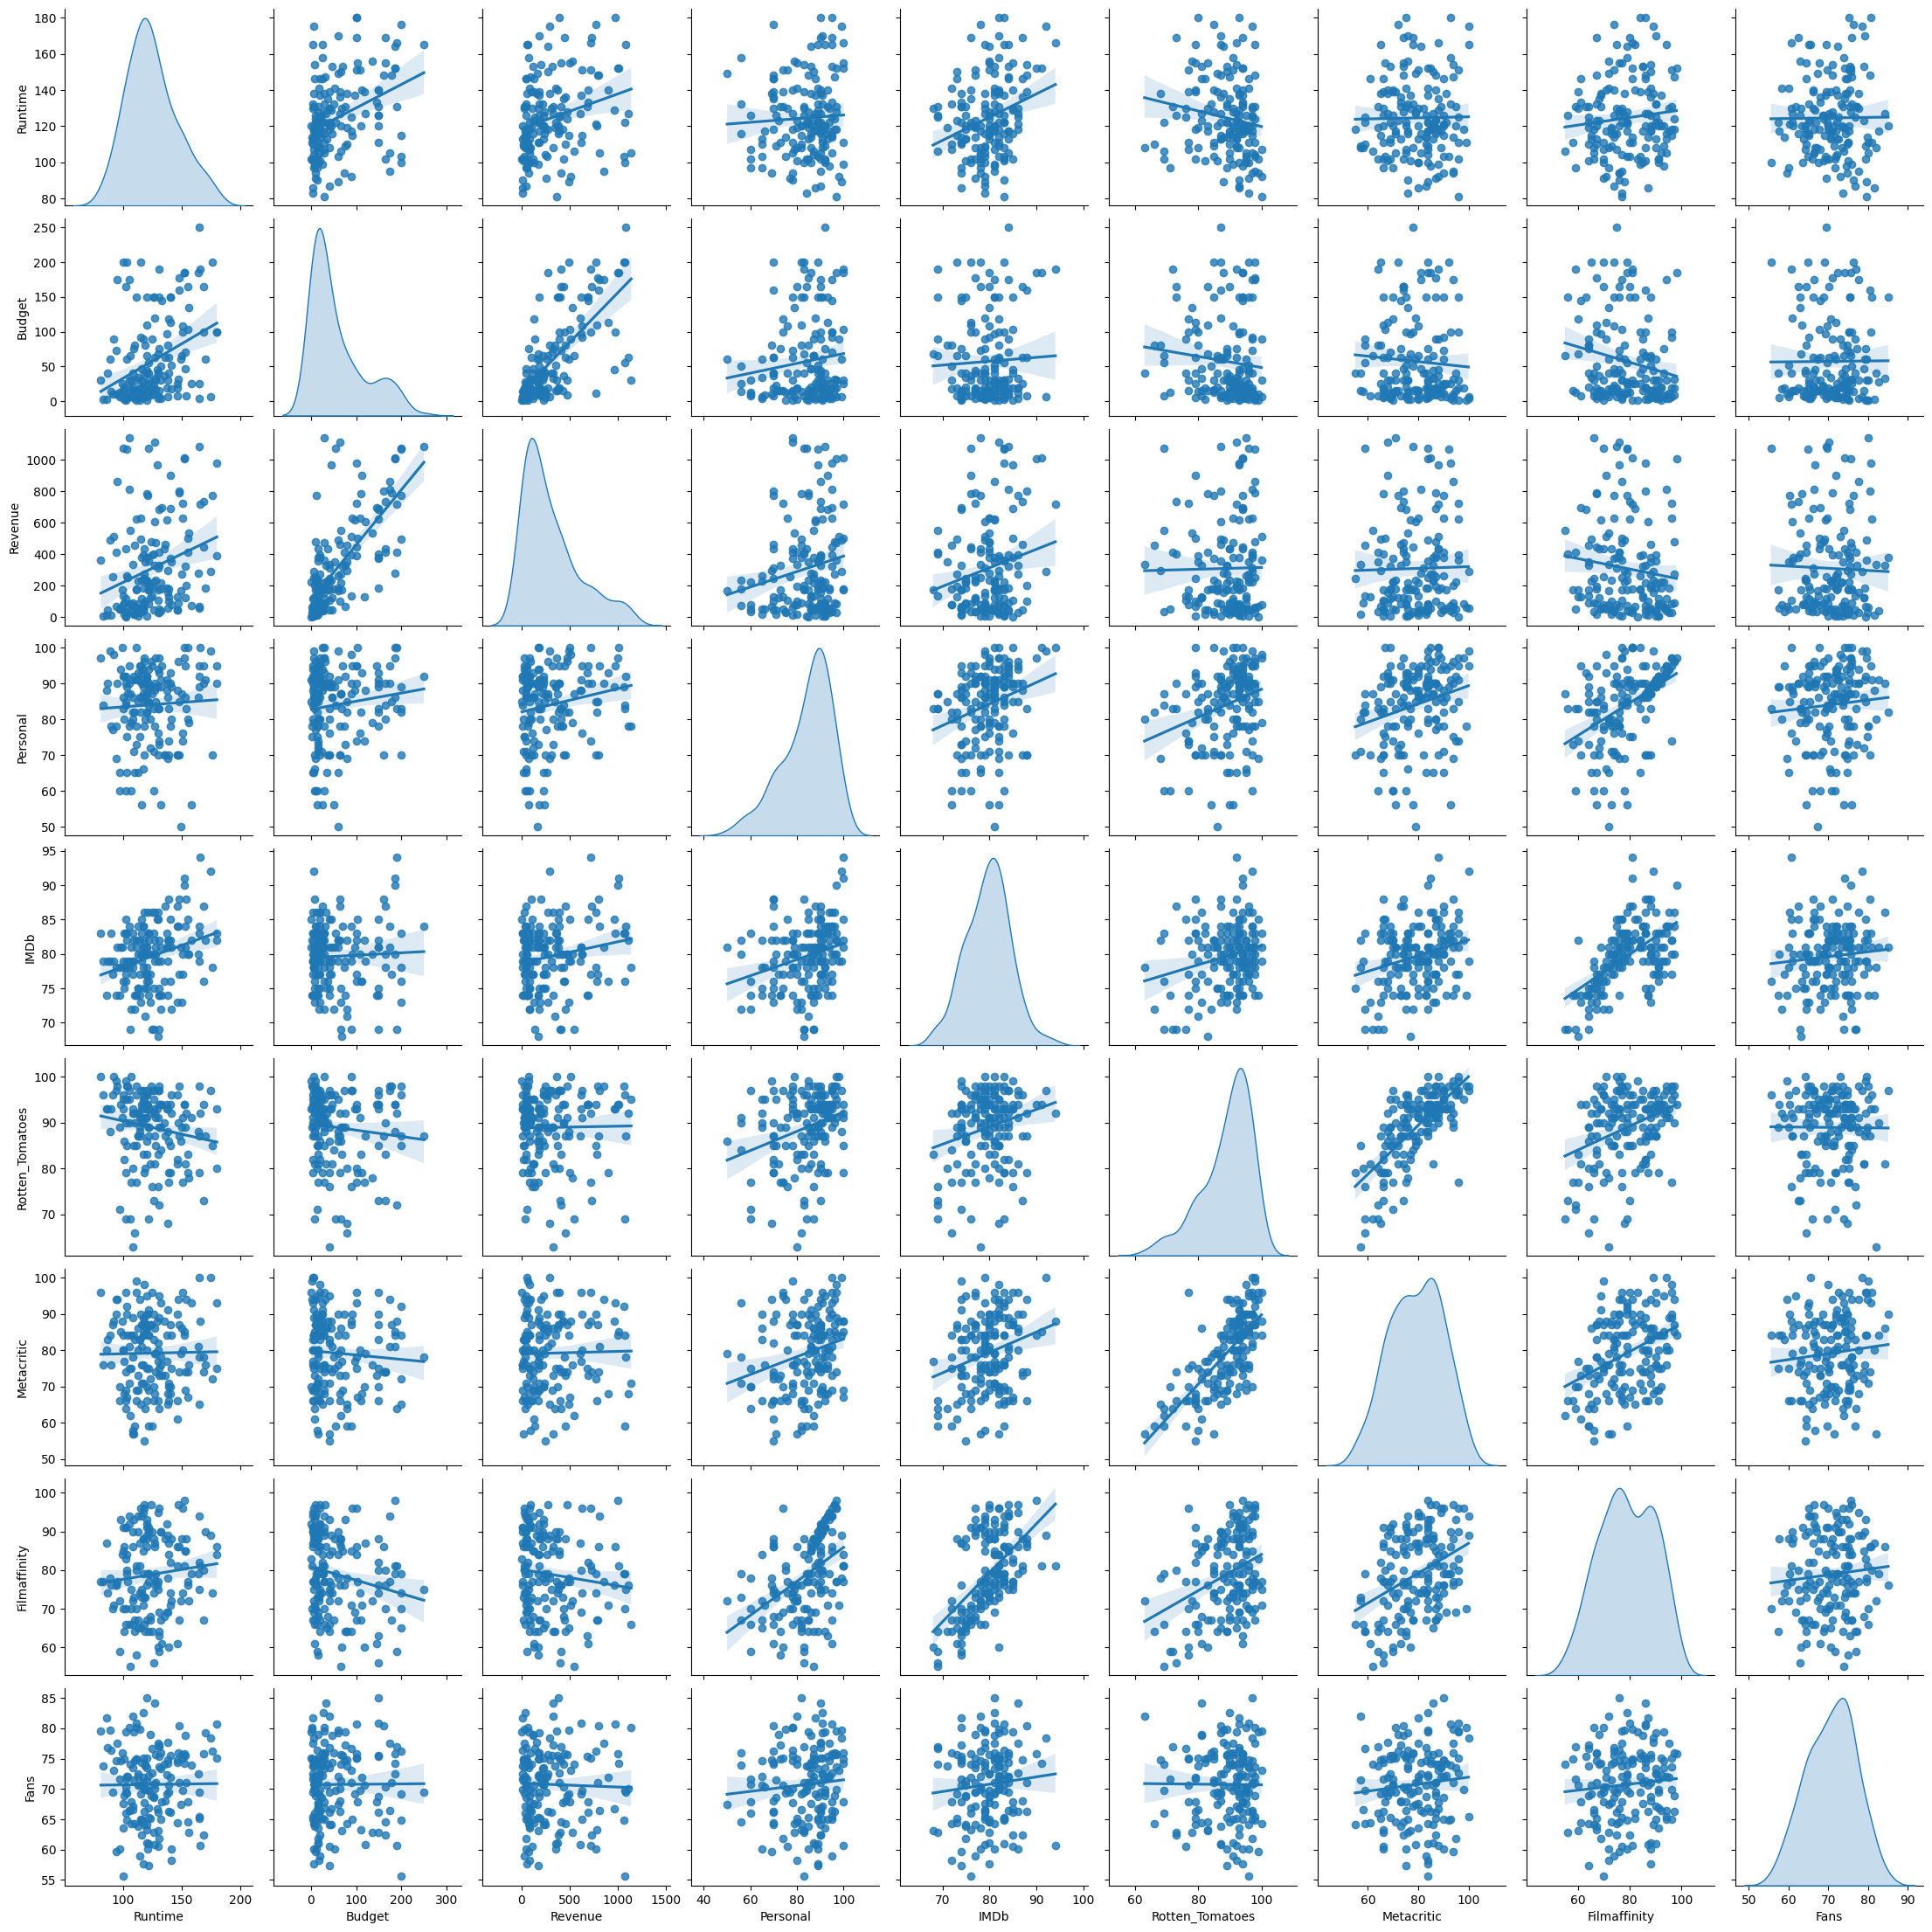

In [64]:
sns.pairplot(movies, height=2.5, kind = 'reg', diag_kind='kde');

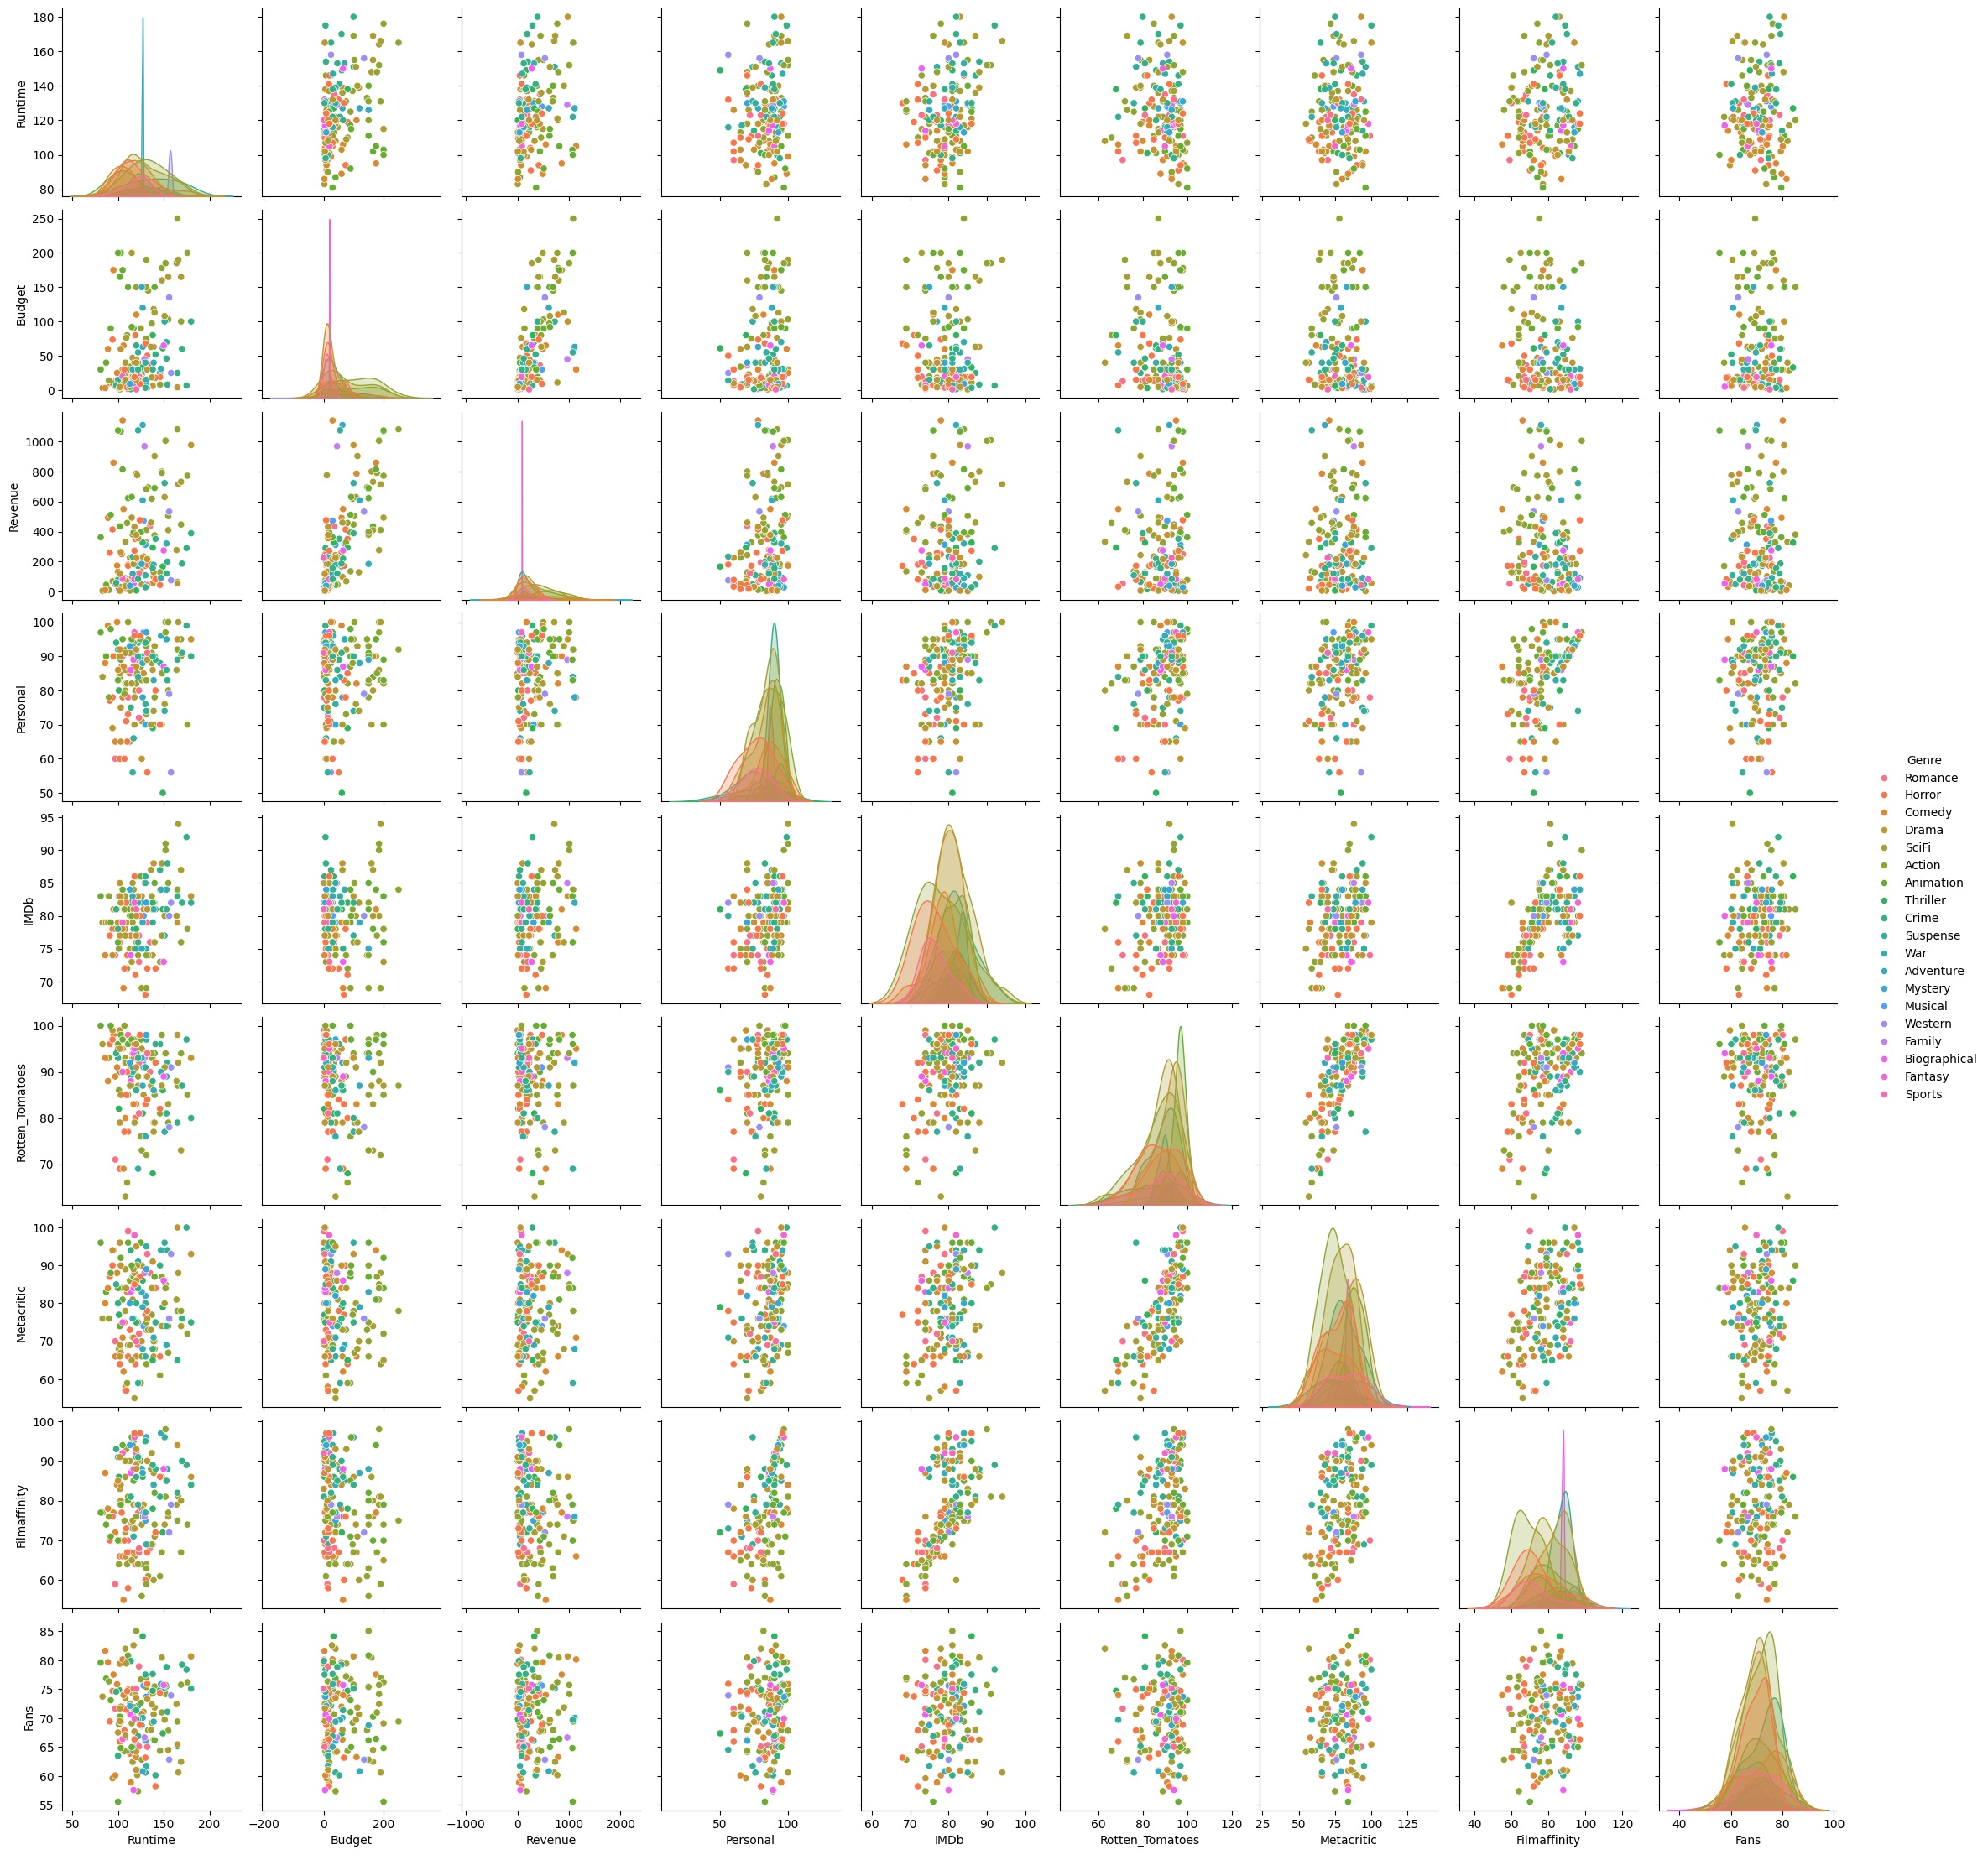

In [65]:
sns.pairplot(movies, height=2.5, hue='Genre');

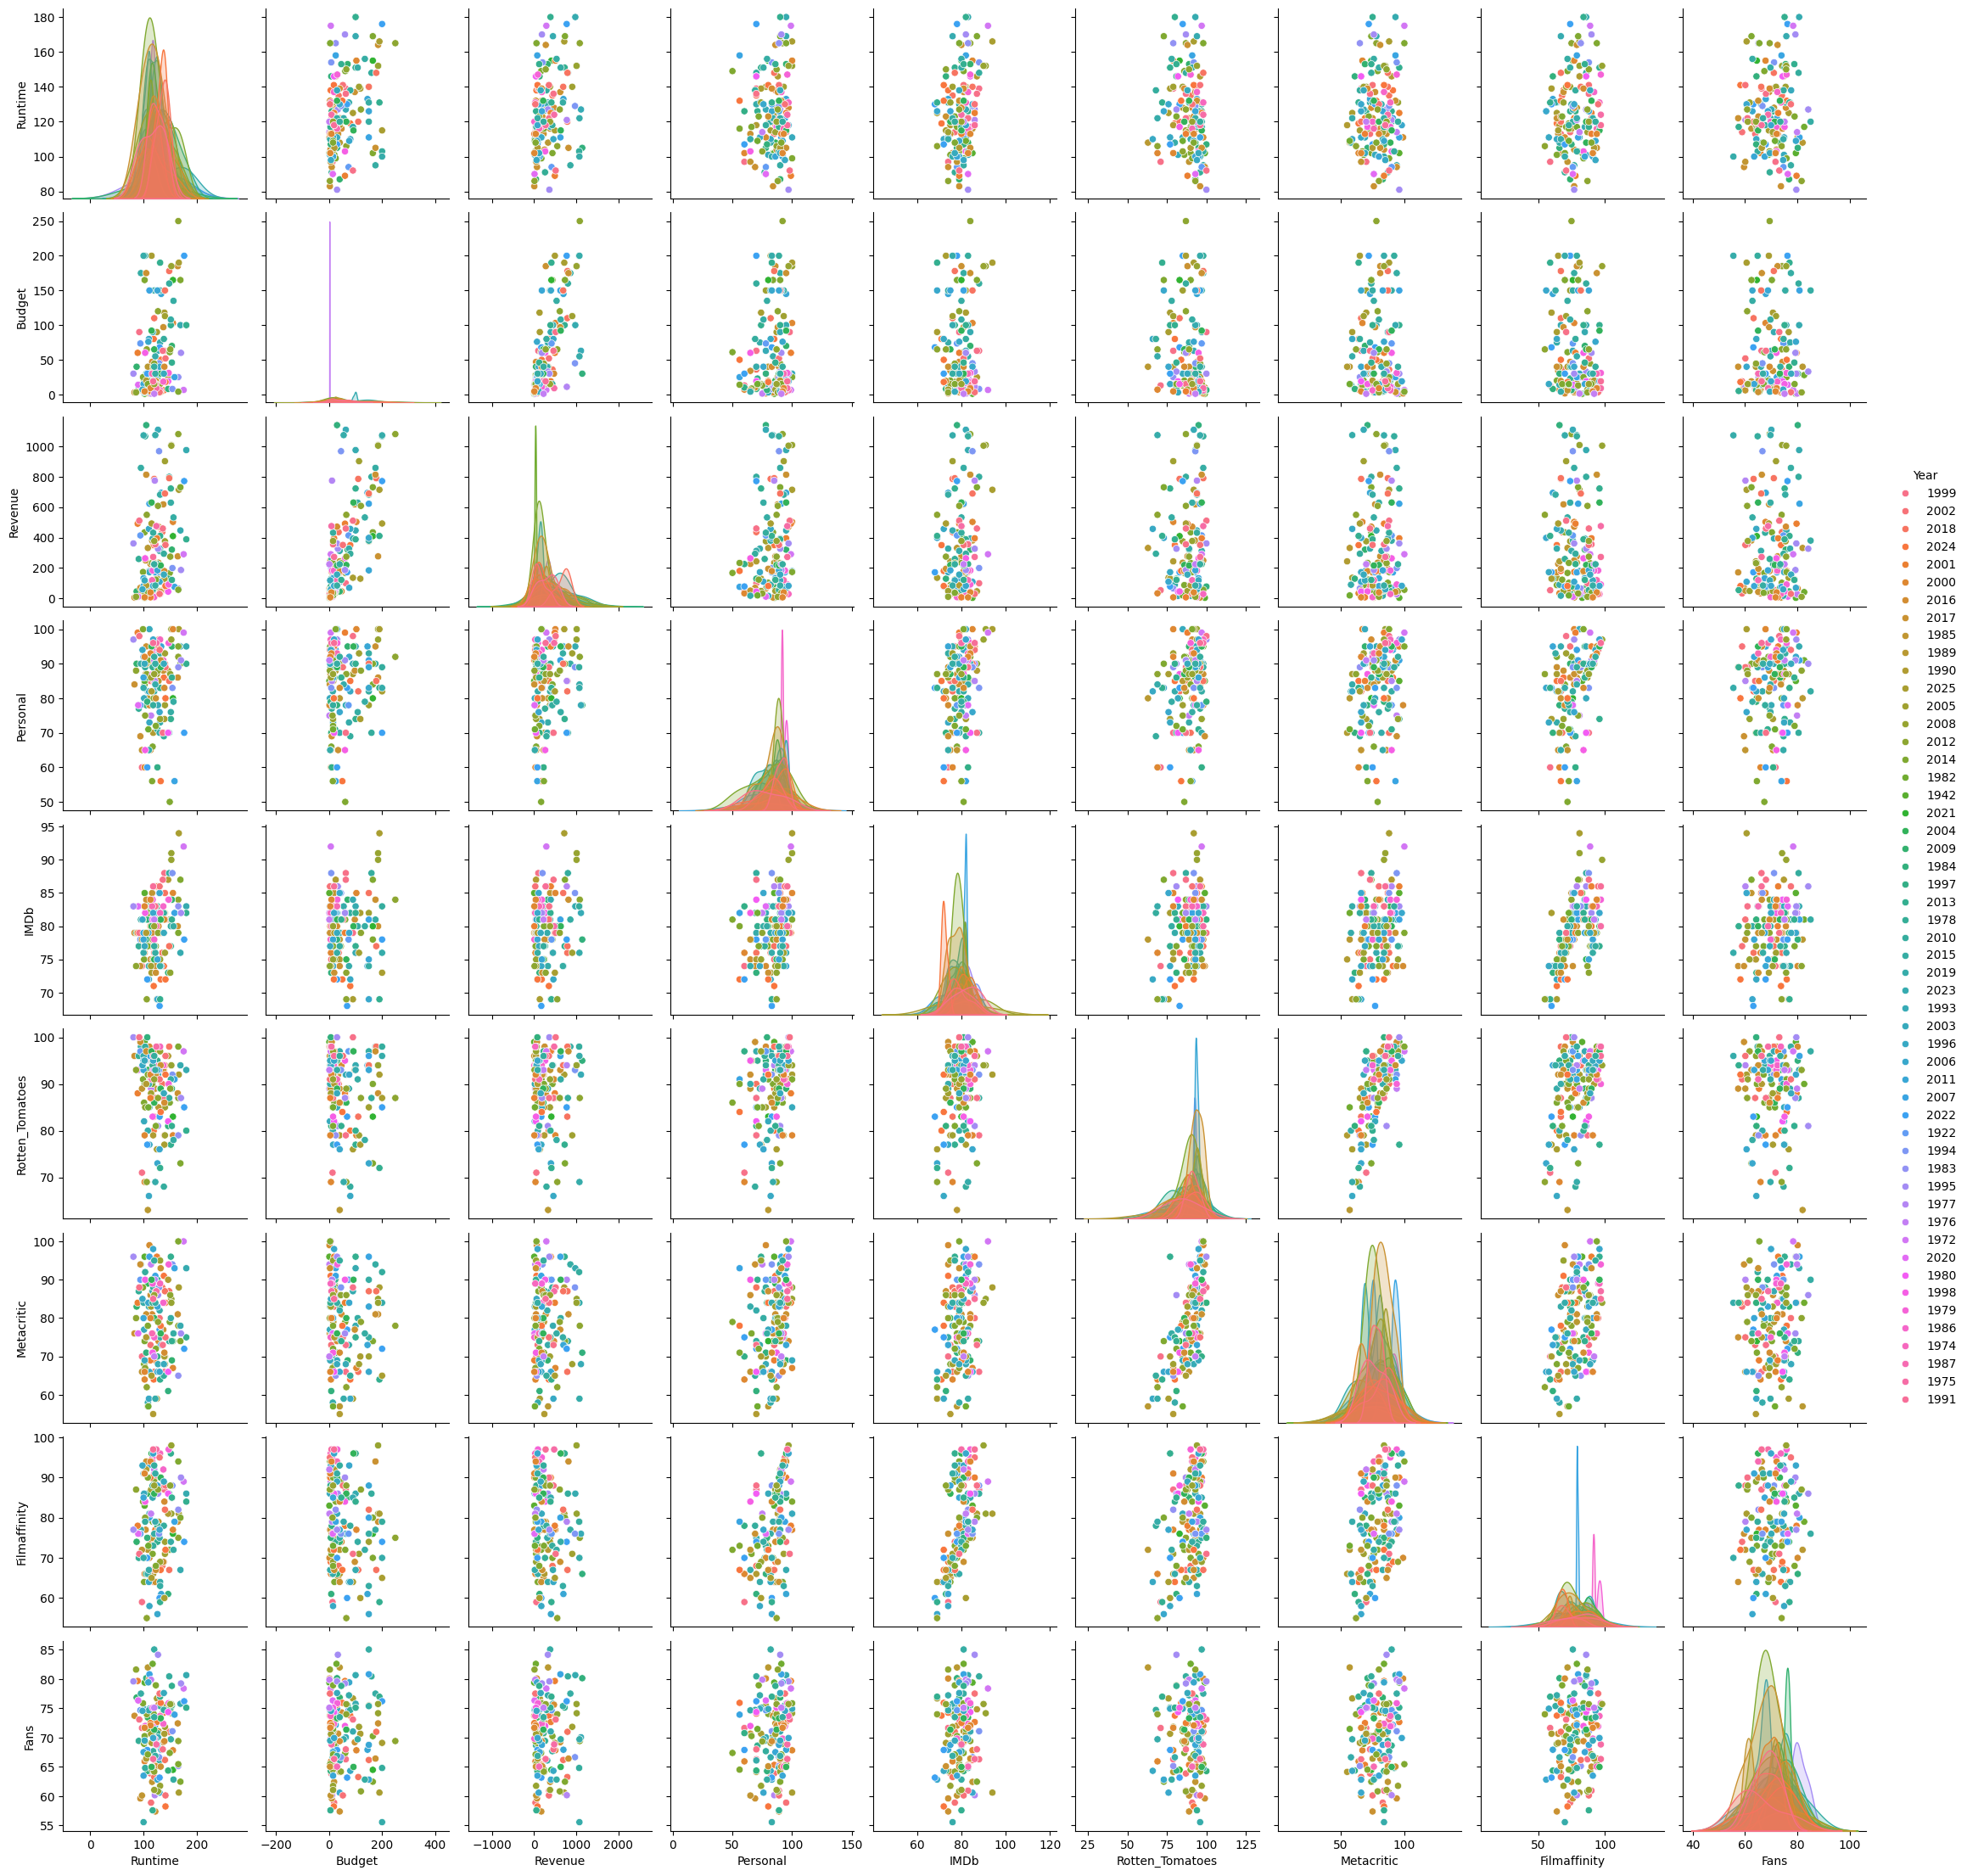

In [66]:
sns.pairplot(movies, height=2.5, hue='Year');

In [67]:
movies.corr(numeric_only=True)

,Runtime,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
Runtime,1.000000,0.358838,0.262836,0.050060,0.283140,-0.157302,0.014326,0.103146,0.008863
Budget,0.358838,1.000000,0.706875,0.126771,0.044627,-0.105238,-0.068619,-0.196578,0.006308
Revenue,0.262836,0.706875,1.000000,0.178430,0.189713,0.014609,0.019446,-0.118990,-0.029216
Personal,0.050060,0.126771,0.178430,1.000000,0.266479,0.286143,0.249571,0.448242,0.081951
IMDb,0.283140,0.044627,0.189713,0.266479,1.000000,0.229246,0.253463,0.571654,0.092599
Rotten_Tomatoes,-0.157302,-0.105238,0.014609,0.286143,0.229246,1.000000,0.711954,0.349806,-0.007032
Metacritic,0.014326,-0.068619,0.019446,0.249571,0.253463,0.711954,1.000000,0.385984,0.097785
Filmaffinity,0.103146,-0.196578,-0.118990,0.448242,0.571654,0.349806,0.385984,1.000000,0.085326
Fans,0.008863,0.006308,-0.029216,0.081951,0.092599,-0.007032,0.097785,0.085326,1.000000


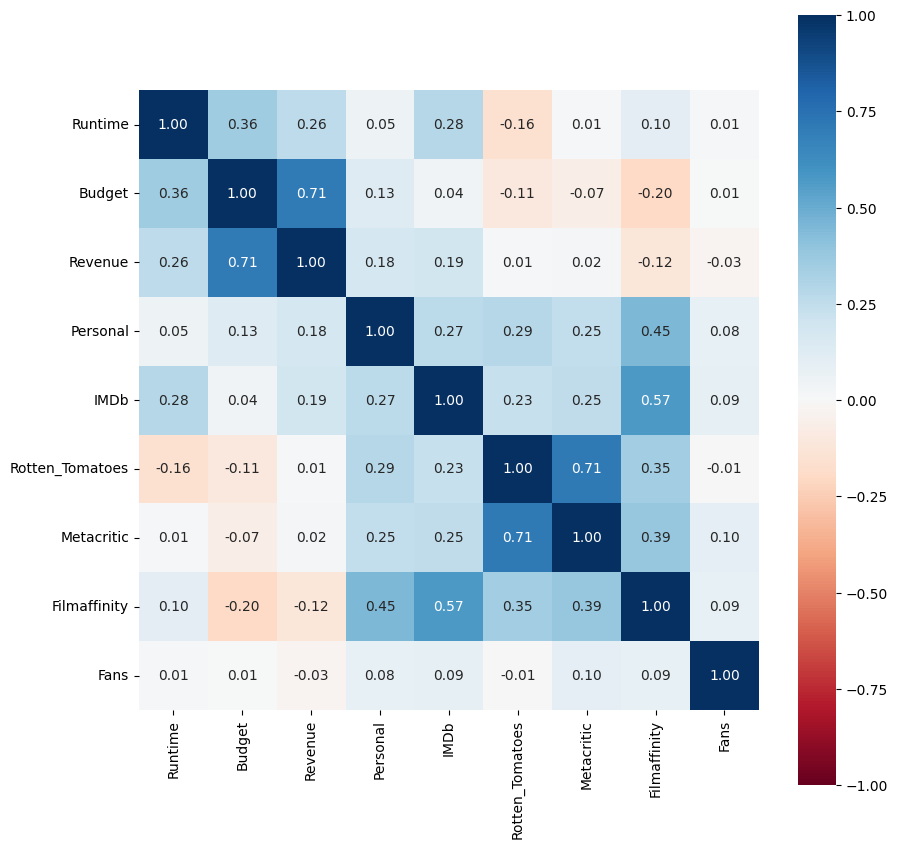

In [68]:
plt.figure(figsize=(10,10))
sns.heatmap(movies.corr(numeric_only=True), annot=True, square=True, cmap='RdBu', vmax=1, vmin=-1,fmt=".2f");

In [69]:
corr = movies.corr(numeric_only=True)
corr[corr<1].max()

Runtime            0.358838
Budget             0.706875
Revenue            0.706875
Personal           0.448242
IMDb               0.571654
Rotten_Tomatoes    0.711954
Metacritic         0.711954
Filmaffinity       0.571654
Fans               0.097785
dtype: float64